# **<a href="https://bsginstitute.com/">BSG Institute</a>**

## **SESION 05: Manipulación y tratamiento de datos con Python**

### Tito Reategui - treateguig@bsginstitue.com

## Programación con librerias en Python

### Numpy - matrices de datos multidimensionales

#### Introducción

NumPy es el paquete fundamental para la computación científica con Python. Contiene, entre otras cosas:

+  un potente objeto matriz N-dimensional/vector/matriz
+  funciones sofisticadas (de transmisión)
+  implementación de funciones en C/Fortran que garantiza un buen rendimiento si se vectorizan
+  herramientas para integrar código C/C++ y Fortran
+  capacidades útiles de álgebra lineal, transformada de Fourier y números aleatorios

También conocido como computación orientada a matrices. La convención recomendada para importar numpy es:

In [ ]:
import numpy as np

En el paquete `numpy`, la terminología utilizada para vectores, matrices y conjuntos de datos de dimensiones superiores es array. Carguemos también algunos otros módulos.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

Ejemplo:  Tira los dados

Te gusta jugar juegos de mesa, pero quieres saber mejor cuáles son tus posibilidades de obtener una determinada combinación con 2 dados:

In [ ]:
def mis_dados(lanzar):
  """
  Función para crear la distribución de la suma de dos dados.

  Parámetros
  ----------
  lanzar : int
  Número de lanzamientos con los dados
  """
  stone1 = np.random.uniform(1, 6, lanzar)
  stone2 = np.random.uniform(1, 6, lanzar)
  total = stone1 + stone2
  return plt.hist(total, bins=20) # Usamos matplotlib para mostrar un histograma

(array([ 3.,  3.,  4.,  3.,  7.,  4.,  3., 10.,  7., 11.,  7., 10.,  7.,
         4.,  4.,  2.,  4.,  3.,  0.,  4.]),
 array([ 2.46854877,  2.90608495,  3.34362114,  3.78115733,  4.21869351,
         4.6562297 ,  5.09376588,  5.53130207,  5.96883825,  6.40637444,
         6.84391062,  7.28144681,  7.71898299,  8.15651918,  8.59405536,
         9.03159155,  9.46912774,  9.90666392, 10.34420011, 10.78173629,
        11.21927248]),
 <BarContainer object of 20 artists>)

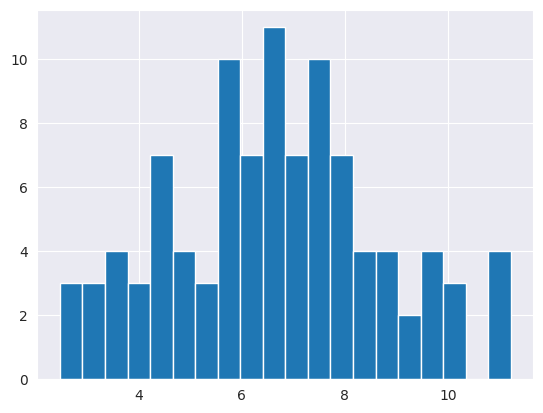

In [ ]:
mis_dados(100)

In [ ]:
type(total2)

numpy.ndarray

Ejemplo: Considere una matriz aleatoria de 10x2 que representa coordenadas cartesianas, cómo convertirlas a coordenadas polares

Text(0.5, 1.0, 'Polar')

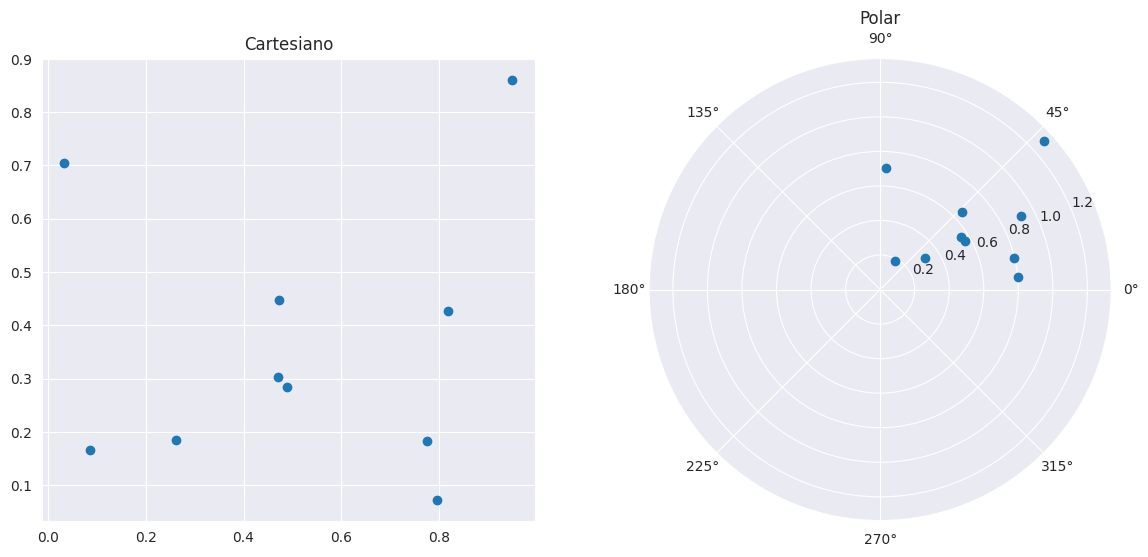

In [ ]:
# números aleatorios (X, Y en 2 columnas)
Z = np.random.random((10,2))
X, Y = Z[:,0], Z[:,1]

# distancia
R = np.sqrt(X**2 + Y**2)
# ángulo
T = np.arctan2(Y, X) # Matriz de ángulos en radianes
Tdegree = T*180/(np.pi) # Convierte los ángulos de radianes a grados, multiplicando por 180/π.

# SIGUIENTE PARTE (ahora para ilustración)
# trace las coordenadas cartesianas
plt.figure(figsize=(14, 6))
ax1 = plt.subplot(121)
ax1.plot(Z[:,0], Z[:,1], 'o')
ax1.set_title("Cartesiano")
#dibuje las coordenadas polares
ax2 = plt.subplot(122, polar=True)
ax2.plot(T, R, 'o')
ax2.set_title("Polar")

In [ ]:
R = [[1, 0],
     [3, 1],
     [5, 7]]

In [ ]:
R_array = np.array(R)

In [ ]:
primera_columna = R_array[:, 1]  # Selecciona la primera columna

In [ ]:
print(primera_columna)

[0 1 7]


#### Creación de matrices numpy

Existen varias formas de inicializar nuevas matrices numpy, por ejemplo, desde


+  una lista o tuplas de Python
+  utilizando funciones dedicadas a generar matrices numpy, como arange, linspace, etc.
+  leyendo datos de archivos

#### Desde listas
Por ejemplo, para crear nuevas matrices de vectores y matrices a partir de listas de Python, podemos utilizar la función numpy.array.

In [ ]:
# un vector: el argumento de la función de matriz es una lista de Python
V = np.array([1, 2, 3, 4])
V


array([1, 2, 3, 4])

In [ ]:
# una matriz: el argumento de la función de matriz es una lista anidada de Python
M = np.array([[1, 2], [3, 4]])
M

array([[1, 2],
       [3, 4]])

Los objetos V y M son ambos del tipo ndarray que proporciona el módulo numpy.



In [ ]:
type(V), type(M)


(numpy.ndarray, numpy.ndarray)

La diferencia entre las matrices `V` y `M` es solo su forma. Podemos obtener información sobre la forma de una matriz utilizando la propiedad `ndarray.shape.`



In [ ]:
V.shape


(4,)

In [ ]:
M.shape

(2, 2)

El número de elementos de la matriz está disponible a través de la propiedad `ndarray.size`:

In [ ]:
M.size

4

De manera equivalente, podríamos usar la función `numpy.shape` y `numpy.size`

In [ ]:
np.shape(M)

(2, 2)

In [ ]:
np.size(M)

4

Usando la propiedad `dtype` (tipo de datos) de un `ndarray` , podemos ver qué tipo tienen los datos de una matriz (siempre fijos para cada matriz.

In [ ]:
M.dtype

dtype('int64')

Obtenemos un error si intentamos asignar un valor del tipo incorrecto a un elemento en una matriz numpy:

In [ ]:
M[0,0] = "hello"


ValueError: invalid literal for int() with base 10: 'hello'

In [ ]:
f = np.array(['lunes', 'martes', 'miercoles', 'jueves'])
f

array(['lunes', 'martes', 'miercoles', 'jueves'], dtype='<U9')

Si queremos, podemos definir explícitamente el tipo de los datos de la matriz cuando la creamos, utilizando el argumento de palabra clave `dtype`:

In [ ]:
M = np.array([[1, 2], [3, 4]], dtype=complex) #np.float64, np.float, np.int64

In [ ]:
print(M, '\n', M.dtype)

[[1.+0.j 2.+0.j]
 [3.+0.j 4.+0.j]] 
 complex128


Dado que las matrices Numpy tienen tipos estáticos, el tipo de una matriz no cambia una vez creada. Pero podemos convertir explícitamente una matriz de un tipo a otro utilizando las funciones `astype` (consulte también la función similar `asarray`). Esto siempre crea una nueva matriz de un nuevo tipo:

In [ ]:
M = np.array([[1.1, 2.1], [3.2, 4.3]], dtype=float)
M2 = M.astype(int)

array([[1, 2],
       [3, 4]])

In [ ]:
M

array([[1.1, 2.1],
       [3.2, 4.3]])

In [ ]:
M2

array([[1, 2],
       [3, 4]])

Los tipos comunes que se pueden utilizar con `dtype` son:
- `int`
- `float`
- `complex`
- `bool`
- `object` , etc.

También podemos definir explícitamente el tamaño de bits de los tipos de datos, por ejemplo:

- `int64`
- `int16`
- `float64`
- `float128`
- `complex128`.

In [ ]:
# una matriz de NumPy con tres dimensiones.
C = np.array([[[1], [2]], [[3], [4]]])
print(C.shape)
C

(2, 2, 1)


array([[[1],
        [2]],

       [[3],
        [4]]])

In [ ]:
# nos da el número de dimensiones
C.ndim

3

#### Usar funciones generadoras de matrices

Para matrices más grandes, no es práctico inicializar los datos manualmente, utilizando listas explícitas de Python. En su lugar, podemos usar una de las muchas funciones de numpy que genera matrices de diferentes formas. Algunos de los más comunes son:

**arange**

In [ ]:
# creamos un arange
x = np.arange(0, 10, 1) # arguments: start, stop, step
x

array([ 0, 10])

In [ ]:
x = np.arange(-1, 1, 0.1)
x

array([-1.00000000e+00, -9.00000000e-01, -8.00000000e-01, -7.00000000e-01,
       -6.00000000e-01, -5.00000000e-01, -4.00000000e-01, -3.00000000e-01,
       -2.00000000e-01, -1.00000000e-01, -2.22044605e-16,  1.00000000e-01,
        2.00000000e-01,  3.00000000e-01,  4.00000000e-01,  5.00000000e-01,
        6.00000000e-01,  7.00000000e-01,  8.00000000e-01,  9.00000000e-01])

**linspace and logspace**

In [ ]:
# al usar linspace, se incluyen ambos puntos finales
np.linspace(0, 10, 25)

array([ 0.        ,  0.41666667,  0.83333333,  1.25      ,  1.66666667,
        2.08333333,  2.5       ,  2.91666667,  3.33333333,  3.75      ,
        4.16666667,  4.58333333,  5.        ,  5.41666667,  5.83333333,
        6.25      ,  6.66666667,  7.08333333,  7.5       ,  7.91666667,
        8.33333333,  8.75      ,  9.16666667,  9.58333333, 10.        ])

In [ ]:
np.logspace(0, 10, 10, base=np.e)

array([1.00000000e+00, 3.03773178e+00, 9.22781435e+00, 2.80316249e+01,
       8.51525577e+01, 2.58670631e+02, 7.85771994e+02, 2.38696456e+03,
       7.25095809e+03, 2.20264658e+04])

**Diferencia clave:**

- **linspace**: Genera números con una separación constante entre ellos.
- **logspace**: Genera números con una separación logarítmica, lo que significa que la diferencia entre los números aumenta a medida que los valores se hacen más grandes.


**¿Cuándo usar cada función?**

- **linspace**: Se utiliza cuando se necesitan valores igualmente espaciados, como para crear ejes de gráficos o evaluar funciones en puntos equidistantes.
- **logspace**: Se utiliza cuando se necesitan valores distribuidos logarítmicamente, como para representar fenómenos físicos que varían exponencialmente o para crear escalas logarítmicas en gráficos.

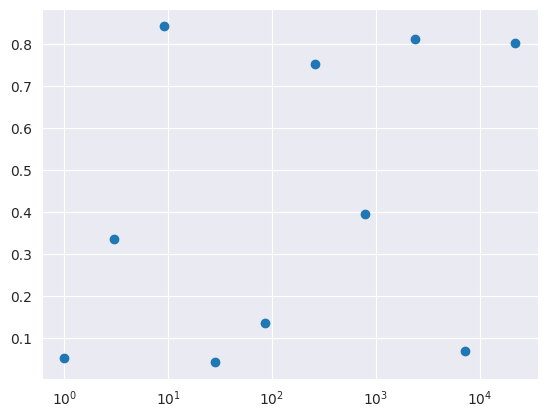

In [ ]:
plt.plot(np.logspace(0, 10, 10, base=np.e), np.random.random(10), 'o')
plt.xscale('log')

**números aleatorios**

In [ ]:
# números aleatorios uniformes en [0,1]
np.random.rand(5,5)

array([[0.26378251, 0.02324707, 0.96836106, 0.50446522, 0.71604208],
       [0.07496207, 0.93029891, 0.58023998, 0.55121915, 0.04290573],
       [0.11714553, 0.2483203 , 0.40568366, 0.18184761, 0.85083832],
       [0.97661795, 0.45081736, 0.23029462, 0.39049733, 0.34191083],
       [0.70772311, 0.91527376, 0.47364823, 0.89506367, 0.0798243 ]])

In [ ]:
# números aleatorios distribuidos normales estándar
np.random.randn(5,5)

array([[-0.53689936,  0.81770312, -1.08124867, -0.50529296, -0.26478439],
       [-0.95425067,  0.86099039, -2.48072522, -0.45673652,  0.79925946],
       [ 0.13449079, -0.91329048,  1.49184825, -1.03700709,  2.57401133],
       [-0.59076998,  1.95060935, -1.01826103, -0.02429344, -2.09566416],
       [ 0.16905562,  0.09250628, -1.13392772,  1.57210528,  0.07692867]])

**ceros y unos**

In [ ]:
np.zeros((3,3))

array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]])

In [ ]:
np.ones((3,3))

array([[1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.]])

EJERCICIO 1.- Crea un vector con valores que van del 10 al 49 con pasos de 1

EJERCICIO 2.- Cree una matriz de identidad de 3x3 (¡consulte los documentos!)

EJERCICIO 3.- Crea una matriz de 3x3x3 con valores aleatorios

**Leer es y escribir archivos con Numpy**

Valores separados por comas (CSV)
La escritura en un archivo `csv` con `numpy` se realiza con el comando `savetxt`:

In [ ]:
import numpy as np

In [ ]:
a = np.random.random(40).reshape((20, 2))
np.savetxt("random-matrix.csv", a, delimiter=",")

Para leer datos de dicho archivo en matrices `Numpy`, podemos usar la función `numpy.genfromtxt`. Por ejemplo,

In [ ]:
a2 = np.genfromtxt("random-matrix.csv", delimiter=',')
a2

array([[0.97861336, 0.07055892],
       [0.92027758, 0.30210942],
       [0.59752748, 0.60640591],
       [0.34481391, 0.04835811],
       [0.8847033 , 0.82422224],
       [0.42310859, 0.7762509 ],
       [0.49218723, 0.39308793],
       [0.89214585, 0.78347168],
       [0.99741369, 0.3185878 ],
       [0.80676243, 0.54332054],
       [0.45114976, 0.70160082],
       [0.24626645, 0.93875195],
       [0.82895662, 0.93451492],
       [0.61547703, 0.24746542],
       [0.23985184, 0.33202444],
       [0.00207435, 0.47985819],
       [0.0825406 , 0.86107978],
       [0.1308607 , 0.68458744],
       [0.27253823, 0.36898864],
       [0.23477433, 0.85086757]])

**Formato de archivo nativo de Numpy**

Útil para almacenar y leer numerosos datos de matrices, desde binarios. Utilice las funciones numpy.save y numpy.load:

In [ ]:
np.save("random-matrix.npy", a) #  La extensión .npy indica que se trata de un archivo NumPy.

In [ ]:
!file random-matrix.npy

random-matrix.npy: NumPy array, version 1.0, header length 118


In [ ]:
np.load("random-matrix.npy")

array([[1.23761226e-01, 8.21828798e-02],
       [2.84122059e-01, 5.23059663e-01],
       [8.43426738e-01, 1.06056393e-01],
       [6.64445613e-01, 7.10301243e-02],
       [8.21842389e-01, 1.67053893e-01],
       [9.01855997e-01, 7.15632466e-01],
       [9.82898735e-01, 5.04687758e-01],
       [7.74996186e-01, 3.99223453e-01],
       [8.45146492e-01, 7.71415716e-01],
       [6.31123710e-01, 2.57175396e-04],
       [5.39321837e-01, 1.82458898e-02],
       [1.87696072e-01, 2.18960465e-01],
       [3.03075627e-02, 4.55845513e-01],
       [2.86422420e-01, 9.93901373e-02],
       [7.17325779e-01, 1.78557370e-01],
       [3.59725691e-01, 7.98018789e-01],
       [5.23972361e-01, 7.00365856e-01],
       [6.55424523e-02, 1.35836983e-01],
       [2.57666528e-01, 7.11012454e-01],
       [4.30794194e-01, 3.90838579e-01]])

#### Manipulación de matrices

**Indexación**

Podemos indexar elementos en una matriz usando corchetes e índices:

In [ ]:
V

array([1, 2, 3, 4])

V es un vector y tiene una sola dimensión, tomando un índice

In [ ]:
V[0]

1

In [ ]:
V[-1:]  #-2, -2:,...

array([4])

In [ ]:
# a es una matriz, o una matriz bidimensional, que toma dos índices
# la primera dimensión corresponde a filas, la segunda a columnas.
a[1, 1]

0.5230596627987191

Si omitimos un índice de una matriz multidimensional, devuelve la fila completa (o, en general, una matriz N-1 dimensional)

In [ ]:
a

array([[0.97861336, 0.07055892],
       [0.92027758, 0.30210942],
       [0.59752748, 0.60640591],
       [0.34481391, 0.04835811],
       [0.8847033 , 0.82422224],
       [0.42310859, 0.7762509 ],
       [0.49218723, 0.39308793],
       [0.89214585, 0.78347168],
       [0.99741369, 0.3185878 ],
       [0.80676243, 0.54332054],
       [0.45114976, 0.70160082],
       [0.24626645, 0.93875195],
       [0.82895662, 0.93451492],
       [0.61547703, 0.24746542],
       [0.23985184, 0.33202444],
       [0.00207435, 0.47985819],
       [0.0825406 , 0.86107978],
       [0.1308607 , 0.68458744],
       [0.27253823, 0.36898864],
       [0.23477433, 0.85086757]])

In [ ]:
a[1]

array([0.92027758, 0.30210942])

Se puede lograr lo mismo usando **:** en lugar de un índice:

In [ ]:
a[1,:] # fila 1


array([0.92027758, 0.30210942])

In [ ]:
a[:, 1] # columna 1

array([0.07055892, 0.30210942, 0.60640591, 0.04835811, 0.82422224,
       0.7762509 , 0.39308793, 0.78347168, 0.3185878 , 0.54332054,
       0.70160082, 0.93875195, 0.93451492, 0.24746542, 0.33202444,
       0.47985819, 0.86107978, 0.68458744, 0.36898864, 0.85086757])

Podemos asignar nuevos valores a elementos de una matriz usando indexación:

In [ ]:
a[0, 0] = 1


In [ ]:
a

array([[1.        , 0.07055892],
       [0.92027758, 0.30210942],
       [0.59752748, 0.60640591],
       [0.34481391, 0.04835811],
       [0.8847033 , 0.82422224],
       [0.42310859, 0.7762509 ],
       [0.49218723, 0.39308793],
       [0.89214585, 0.78347168],
       [0.99741369, 0.3185878 ],
       [0.80676243, 0.54332054],
       [0.45114976, 0.70160082],
       [0.24626645, 0.93875195],
       [0.82895662, 0.93451492],
       [0.61547703, 0.24746542],
       [0.23985184, 0.33202444],
       [0.00207435, 0.47985819],
       [0.0825406 , 0.86107978],
       [0.1308607 , 0.68458744],
       [0.27253823, 0.36898864],
       [0.23477433, 0.85086757]])

In [ ]:
a[:, 1] = -1

In [ ]:
a

array([[ 1.        , -1.        ],
       [ 0.92027758, -1.        ],
       [ 0.59752748, -1.        ],
       [ 0.34481391, -1.        ],
       [ 0.8847033 , -1.        ],
       [ 0.42310859, -1.        ],
       [ 0.49218723, -1.        ],
       [ 0.89214585, -1.        ],
       [ 0.99741369, -1.        ],
       [ 0.80676243, -1.        ],
       [ 0.45114976, -1.        ],
       [ 0.24626645, -1.        ],
       [ 0.82895662, -1.        ],
       [ 0.61547703, -1.        ],
       [ 0.23985184, -1.        ],
       [ 0.00207435, -1.        ],
       [ 0.0825406 , -1.        ],
       [ 0.1308607 , -1.        ],
       [ 0.27253823, -1.        ],
       [ 0.23477433, -1.        ]])

**Segmentación de índice**

La división de índice es el nombre técnico de la sintaxis `M[inferior:superior:paso]` para extraer parte de una matriz:

In [ ]:
A = np.array([1, 2, 3, 4, 5])
A

array([1, 2, 3, 4, 5])

In [ ]:
A[1:3]

array([2, 3])

Los segmentos de la matriz son mutables: si se les asigna un nuevo valor, se modifica la matriz original de la que se extrajo el sector:

In [ ]:
A[1:3] = [-2,-3]
A

array([ 1, -2, -3,  4,  5])

Podemos omitir cualquiera de los tres parámetros en `M[inferior:superior:paso]`:

In [ ]:
A[::] # inferior, superior, paso, toma todos los valores predeterminados

array([ 1, -2, -3,  4,  5])

In [ ]:
A[::2] # un paso de 2,se seleccionará cada segundo elemento del arreglo.

array([ 1, -3,  5])

In [ ]:
A[:3] # primeros tres elementos

array([ 1, -2, -3])

In [ ]:
A[3:] # elementos del índice 3

array([4, 5])

In [ ]:
A[-3:] # los últimos tres elementos

array([-3,  4,  5])

In [ ]:
A[:-3]

array([ 1, -2])

EJERCICIO 4.- Crea un vector nulo de tamaño 10 y adáptalo para hacer que el quinto elemento tome el valor 1

In [ ]:
vector_nulo = np.zeros(10)
vector_nulo[4] = 1.
print(vector_nulo)

[0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]


**Indexación elegante**

La indexación elegante es el nombre que se le da a cuando se usa una matriz o lista en lugar de un índice:

In [ ]:
a = np.arange(0, 100, 10)
a

array([ 0, 10, 20, 30, 40, 50, 60, 70, 80, 90])

In [ ]:
a[[2, 3, 2, 4, 2]]

array([20, 30, 20, 40, 20])

**En más dimensiones**

In [ ]:
A = np.arange(25).reshape(5,5)
A

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14],
       [15, 16, 17, 18, 19],
       [20, 21, 22, 23, 24]])

In [ ]:
row_indices = [0, 1, 3]
A[row_indices]

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [15, 16, 17, 18, 19]])

In [ ]:
col_indices = [1, 2, -1] # recuerda, el índice -1 significa el último elemento

In [ ]:
# Aquí se combina la selección de filas y columnas.
A[row_indices, col_indices]

array([ 1,  7, 19])

También podemos indexar máscaras: Si la máscara de índice es una matriz Numpy con tipo de datos`bool`, entonces se selecciona un elemento (Verdadero) o no (Falso) dependiendo del valor de la máscara de índice en la posición de cada elemento:

In [ ]:
import numpy as np

arr = np.array([1, 2, 3, 4])
mask = np.array([True, False, True, False])
resultado = arr[mask]
print(resultado)  # Imprime: [1 3]

[1 3]


In [ ]:
B = np.array([n for n in range(5)])
B

array([0, 1, 2, 3, 4])

In [ ]:
row_mask = np.array([True, False, True, False, False])
resultado2 = B[row_mask]
print(resultado2)

[0 2]


Esta característica es muy útil para seleccionar condicionalmente elementos de una matriz, usando por ejemplo operadores de comparación:

In [ ]:
AR = np.random.randint(0, 20, 15)

In [ ]:
AR%3 == 0

array([False, False, False, False,  True,  True, False, False,  True,
       False, False, False, False, False, False])

In [ ]:
extract_from_AR = AR[AR%3 == 0]
extract_from_AR

In [ ]:
x = np.arange(0, 10, 0.5)
x

array([0. , 0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. , 5.5, 6. ,
       6.5, 7. , 7.5, 8. , 8.5, 9. , 9.5])

In [ ]:
mask = (5 < x) * (x < 7.5) # En realidad, aquí multiplicamos dos máscaras (valores booleanos 0 y 1)
mask

array([False, False, False, False, False, False, False, False, False,
       False, False,  True,  True,  True,  True, False, False, False,
       False, False])

In [ ]:
x[mask]

array([5.5, 6. , 6.5, 7. ])

EJERCICIO 5.-intercambiar las dos primeras filas de una matriz 2D utilizando NumPy

EJERCICIO 6.- Cambie todos los números pares de AR a valores cero.

EJERCICIO 7.-Cambie todas las posiciones pares de la matriz `AR` a valores cero

#### Algunas funciones de extracción

donde la función es para conocer los índices de alguna matriz


In [ ]:
x = np.arange(0, 10, 0.5)
x

array([0. , 0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. , 5.5, 6. ,
       6.5, 7. , 7.5, 8. , 8.5, 9. , 9.5])

In [ ]:
# np.where(): Esta función se utiliza para encontrar los índices de los elementos que cumplen una determinada condición.
np.where(x>5.)

(array([11, 12, 13, 14, 15, 16, 17, 18, 19]),)

Con la función `diag` también podemos extraer las diagonales y subdiagonales de un array:

    np.diag(A)

La función `take` es similar a la indexación elegante descrita anteriormente:

In [ ]:
x.take([1, 5])

array([0.5, 2.5])

#### Operaciones de matriz-matriz por elementos

Cuando sumamos, restamos, multiplicamos y dividimos matrices entre sí, el comportamiento predeterminado son operaciones de elementos:

In [ ]:
v1 = np.arange(0, 5)

In [ ]:
v1

array([0, 1, 2, 3, 4])

In [ ]:
v1 * 2

array([0, 2, 4, 6, 8])

In [ ]:
v1 + 2

array([2, 3, 4, 5, 6])

In [ ]:
A = np.arange(25).reshape(5,5)
A * 2

array([[ 0,  2,  4,  6,  8],
       [10, 12, 14, 16, 18],
       [20, 22, 24, 26, 28],
       [30, 32, 34, 36, 38],
       [40, 42, 44, 46, 48]])

In [ ]:
A

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14],
       [15, 16, 17, 18, 19],
       [20, 21, 22, 23, 24]])

In [ ]:
np.sin(A)

array([[ 0.        ,  0.84147098,  0.90929743,  0.14112001, -0.7568025 ],
       [-0.95892427, -0.2794155 ,  0.6569866 ,  0.98935825,  0.41211849],
       [-0.54402111, -0.99999021, -0.53657292,  0.42016704,  0.99060736],
       [ 0.65028784, -0.28790332, -0.96139749, -0.75098725,  0.14987721],
       [ 0.91294525,  0.83665564, -0.00885131, -0.8462204 , -0.90557836]])

In [ ]:
A * A # multiplicación por elementos

array([[  0,   1,   4,   9,  16],
       [ 25,  36,  49,  64,  81],
       [100, 121, 144, 169, 196],
       [225, 256, 289, 324, 361],
       [400, 441, 484, 529, 576]])

In [ ]:
v1 * v1

array([ 0,  1,  4,  9, 16])

Si multiplicamos matrices con formas compatibles, obtenemos una multiplicación por elementos de cada fila:

In [ ]:
A.shape, v1.shape


((5, 5), (5,))

In [ ]:
R = A * v1
R


array([[ 0,  1,  4,  9, 16],
       [ 0,  6, 14, 24, 36],
       [ 0, 11, 24, 39, 56],
       [ 0, 16, 34, 54, 76],
       [ 0, 21, 44, 69, 96]])

In [ ]:
R.shape

(5, 5)

In [ ]:
import numpy as np

Z = np.arange(25).reshape(5,5)
b = np.arange(0, 5)
resultado = np.dot(Z, b)  # Producto punto

In [ ]:
resultado

array([ 30,  80, 130, 180, 230])

In [ ]:
A.shape

(5, 5)

In [ ]:
b.shape

(5,)

In [ ]:
resultado.shape

(5,)

Considere la diferencia de velocidad con Python puro:

In [ ]:
a = np.arange(10000)
%timeit a + 1

l = range(10000)
%timeit [i+1 for i in l]

6.01 µs ± 1.51 µs per loop (mean ± std. dev. of 7 runs, 100000 loops each)
719 µs ± 13.4 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


In [ ]:
#logical operators:
a1 = np.arange(0, 5, 1)
a2 = np.arange(5, 0, -1)
a1>a2  # >, <=,...

array([False, False, False,  True,  True])

In [ ]:
# cfr.
np.all(a1>a2) # verificará que todos los elementos de este array son True


False

#### Algebra de matrices



¿Qué pasa con la multiplicación de matrices? Hay dos maneras. Podemos usar la función de punto, que aplica una multiplicación matriz-matriz, matriz-vector o vector interno a sus dos argumentos:

In [ ]:
np.dot(A, A)

array([[ 150,  160,  170,  180,  190],
       [ 400,  435,  470,  505,  540],
       [ 650,  710,  770,  830,  890],
       [ 900,  985, 1070, 1155, 1240],
       [1150, 1260, 1370, 1480, 1590]])

In [ ]:
np.dot(A, v1)

array([ 30,  80, 130, 180, 230])

In [ ]:
np.dot(v1, v1)

30

Alternativamente, podemos convertir los objetos de la matriz al tipo de matriz. Esto cambia el comportamiento de los operadores aritméticos estándar +, -, * para usar álgebra matricial. También puedes obtener inversas de matrices, determinantes,etc.



No profundizaremos aquí en el cálculo matricial puro, pero para obtener más información, consulte las funciones relacionadas: interna, externa, cruzada, kron, tensordot. Pruebe, por ejemplo, help(kron).

In [ ]:
import numpy as np
help(np.kron)

Help on _ArrayFunctionDispatcher in module numpy:

kron(a, b)
    Kronecker product of two arrays.
    
    Computes the Kronecker product, a composite array made of blocks of the
    second array scaled by the first.
    
    Parameters
    ----------
    a, b : array_like
    
    Returns
    -------
    out : ndarray
    
    See Also
    --------
    outer : The outer product
    
    Notes
    -----
    The function assumes that the number of dimensions of `a` and `b`
    are the same, if necessary prepending the smallest with ones.
    If ``a.shape = (r0,r1,..,rN)`` and ``b.shape = (s0,s1,...,sN)``,
    the Kronecker product has shape ``(r0*s0, r1*s1, ..., rN*SN)``.
    The elements are products of elements from `a` and `b`, organized
    explicitly by::
    
        kron(a,b)[k0,k1,...,kN] = a[i0,i1,...,iN] * b[j0,j1,...,jN]
    
    where::
    
        kt = it * st + jt,  t = 0,...,N
    
    In the common 2-D case (N=1), the block structure can be visualized::
    
        [[

**Cálculos**


A menudo resulta útil almacenar conjuntos de datos en matrices Numpy. Numpy proporciona una serie de funciones para calcular estadísticas de conjuntos de datos en matrices.

In [ ]:
a = np.random.random(40)

Se pueden realizar diferentes operaciones de uso frecuente:

In [ ]:
print ('valor de la media', np.mean(a))
print ('Mvalor de la mediana',  np.median(a))
print ('la Std', np.std(a))
print ('la Variance es', np.var(a))
print ('el Min es', a.min())
print ('Elemento de valor minimo', a.argmin()) # Devuelve el índice del primer valor mínimo
print ('el Max es', a.max())
print ('la suma es', np.sum(a))
print ('Prod', np.prod(a))
print ('Cumsum is', np.cumsum(a)[-1]) # es una forma eficiente de calcular la suma de todos los elementos
print ('CumProd of 5 first elements is', np.cumprod(a)[4]) # e da el producto acumulado hasta el quinto elemento
print ('Unique values in this array are:', np.unique(np.random.randint(1,6,10))) # te dará un arreglo que contiene los números únicos
print ('85% Percentile value is: ', np.percentile(a, 85))
print ('85% Percentile value is: ', np.percentile(a, 95))

valor de la media 0.5599464506850277
Mvalor de la mediana 0.5157019413085022
la Std 0.2902310431643873
la Variance es 0.08423405841628843
el Min es 0.00559410969954921
Elemento de valor minimo 28
el Max es 0.999473466134841
la suma es 22.397858027401107
Prod 1.04111378604869e-15
Cumsum is 22.39785802740111
CumProd of 5 first elements is 0.00853871731796195
Unique values in this array are: [1 2 3 4 5]
85% Percentile value is:  0.9189233905216699
85% Percentile value is:  0.9676933302952107


In [ ]:
import numpy as np
a = np.random.random(40)
print(a.argsort())
a.sort() #Ordena en su lugar
print(a.argsort())

[10 28 35 21 37  1 30 27 38 26  0  4 32  9  3 34 13 18 39 29 19 12 17  8
 20 15 33  6 31 11  7 22 24 36 16 14 23  2  5 25]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39]


#### Cálculos con datos de dimensiones superiores

Cuando se aplican funciones como **`min`**, **`max`**, etc. a matrices multidimensionales, a veces resulta útil aplicar el cálculo a toda la matriz y, a veces, solo a una fila o columna. Mediante el argumento **`axis`** podemos especificar cómo deben comportarse estas funciones:

In [ ]:
m = np.random.rand(3,3)
m

array([[0.95548604, 0.45243346, 0.33083206],
       [0.88803004, 0.45056576, 0.82810919],
       [0.9861739 , 0.5656999 , 0.15959213]])

In [ ]:
# Máx glogal
m.max()

0.9861738951106527

In [ ]:
# max en cada columna
m.max(axis=0)

array([0.9861739 , 0.5656999 , 0.82810919])

In [ ]:
# max en cada fila
m.max(axis=1)

array([0.95548604, 0.88803004, 0.9861739 ])

Muchas otras funciones y métodos en las clases de `matrices` y `array` aceptan el mismo argumento de palabra clave de `axis` (opcional).

EJERCICIO 08: Reescalar (estandarizar) la matriz `Z` 5x5  a valores entre 0 y 1:

In [ ]:
Z = np.random.uniform(5.0, 15.0, (5,5))
Z

array([[11.73785827, 10.64275932,  7.93243456,  5.69699404, 11.9589446 ],
       [10.73178966, 14.8405725 ,  7.64247481, 13.95322975, 10.60726695],
       [ 6.46775328, 13.73486551, 10.12273836, 14.10529565,  6.40394961],
       [ 8.77631497,  8.5464708 ,  5.60043254,  5.19018082, 13.01016104],
       [10.42550605, 14.84676268,  7.94736845,  9.4067431 ,  8.17833797]])

In [ ]:
# REESCALA:
(Z - Z.min())/(Z.max() - Z.min())

array([[0.67805333, 0.56464892, 0.28397768, 0.05248371, 0.70094821],
       [0.57386857, 0.99935897, 0.25395052, 0.90746903, 0.56097346],
       [0.13230069, 0.88485603, 0.51079747, 0.92321641, 0.12569342],
       [0.37136683, 0.34756501, 0.04248415, 0.        , 0.80980831],
       [0.54215097, 1.        , 0.28552418, 0.43665164, 0.30944253]])

#### Reformar, cambio de tamaño y apilamiento de matrices

La forma (shape) de una matriz de **Numpy** se puede modificar sin copiar los datos subyacentes, lo que la convierte en una operación rápida incluso para matrices de gran tamaño.

In [ ]:
# crear una matriz unidimensional que contiene los números del 0 al 24.
A = np.arange(25).reshape(5,5) # Reestructura la matriz Aen una matriz de 5x5.
n, m = A.shape # extrae las dimensiones de la matriz reformada A

# Reforma la matriz nuevamente
B = A.reshape((1,n*m))
B

array([[ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
        16, 17, 18, 19, 20, 21, 22, 23, 24]])

También podemos utilizar la función **`flatten`** para convertir una matriz de dimensiones superiores en un vector. Pero esta función crea una copia de los datos (ver a continuación)

In [ ]:
B = A.flatten()
B

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24])

#### Apilar y repetición de matrices

Usando las funciones **repeat**, **tile**, **vstack**, **hstack** y **concatenate** podemos crear vectores y matrices más grandes a partir de matrices más pequeñas:

**tile y repeat**

In [ ]:
a = np.array([[1, 2], [3, 4]])

In [ ]:
# repite cada elemento 3 veces
np.repeat(a, 3)

array([1, 1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 4])

In [ ]:
# Colocar la matriz en mosaico 3 veces
t= np.tile(a, 3)

In [ ]:
t

array([[1, 2, 1, 2, 1, 2],
       [3, 4, 3, 4, 3, 4]])

**Concatenate**

In [ ]:
b = np.array([[5, 6]])

In [ ]:
# concatena las matrices a y b a lo largo del eje 0 (filas)
np.concatenate((a, b), axis=0)

array([[1, 2],
       [3, 4],
       [5, 6]])

In [ ]:
# la operación .T. Esta operación transpone el array b
np.concatenate((a, b.T), axis=1)

array([[1, 2, 5],
       [3, 4, 6]])

**hstack y vstack**


+ hstack (horizontal stack): Combina múltiples matrices horizontalmente, es decir, una al lado de la otra. Para que esta operación sea posible, las matrices deben tener el mismo número de filas.

+ vstack (vertical stack): Combina múltiples matrices verticalmente, una encima de la otra. En este caso, las matrices deben tener el mismo número de columnas.

In [ ]:
np.vstack((a,b))

array([[1, 2],
       [3, 4],
       [5, 6]])

In [ ]:
np.hstack((a,b.T))

array([[1, 2, 5],
       [3, 4, 6]])

**IMPORTANTE: Ver y copiar**

Para lograr un alto rendimiento, las asignaciones en Python normalmente no copian los objetos subyacentes. Esto es importante, por ejemplo, cuando se pasan objetos entre funciones, para evitar una cantidad excesiva de copia de memoria cuando no es necesario (término técnico: pasar por referencia).

In [ ]:
A = np.array([[1, 2], [3, 4]])
A

array([[1, 2],
       [3, 4]])

In [ ]:
# ahora B hace referencia a los mismos datos de la matriz que A
B = A

In [ ]:
# cambiar B afecta a A
B[0,0] = 10
B

array([[10,  2],
       [ 3,  4]])

In [ ]:
A

array([[10,  2],
       [ 3,  4]])

**Si queremos evitar este comportamiento**, de modo que cuando obtengamos un nuevo objeto `B` completamente independiente copiado de `A`, entonces necesitaremos hacer una llamada "copia profunda" utilizando la función **`copy`**:

In [ ]:
B = np.copy(A)

In [ ]:
# ahora, si modificamos B, A no se ve afectado
B[0,0] = -5

B

array([[-5,  2],
       [ 3,  4]])

In [ ]:
A

array([[10,  2],
       [ 3,  4]])

Además, la función **reshape** solo toma una vista:

In [ ]:
arr = np.arange(8)
arr_view = arr.reshape(2, 4)

In [ ]:
arr

array([0, 1, 2, 3, 4, 5, 6, 7])

In [ ]:
arr_view

array([[0, 1, 2, 3],
       [4, 5, 6, 7]])

In [ ]:
print('Antes\n', arr_view)
arr[0] = 1000
print('Después\n', arr_view)

Antes
 [[0 1 2 3]
 [4 5 6 7]]
Después
 [[1000    1    2    3]
 [   4    5    6    7]]


In [ ]:
arr

array([1000,    1,    2,    3,    4,    5,    6,    7])

In [ ]:
arr_copia = arr.copy()

Aplanamiento y modificación de un elemento:

In [ ]:
arr_copia.flatten()[2] = 10   #¡Flatten crea una copia!

In [ ]:
arr_copia

array([1000,    1,    2,    3,    4,    5,    6,    7])

#### Uso de matrices en condiciones

Al utilizar matrices en condiciones, por ejemplo, en declaraciones **`if`** y otras expresiones booleanas, es necesario utilizar una de las opciones **`any`** o **`all`**, lo que requiere que cualquiera o todos los elementos de la matriz evalúen como verdaderos:

In [ ]:
M = np.array([[5, 5, 7], [13, 14, 5]])

In [ ]:
if (M > 5).any():
  print("al menos un elemento en M es mayor que 5")
else:
  print("ningún elemento en M es mayor que 5")

al menos un elemento en M es mayor que 5


In [ ]:
if (M > 5).all():
  print("todos los elementos en M son mayores que 5")
else:
  print("todos los elementos en M no son mayores que 5")

todos los elementos en M no son mayores que 5


**Otras aplicaciones**

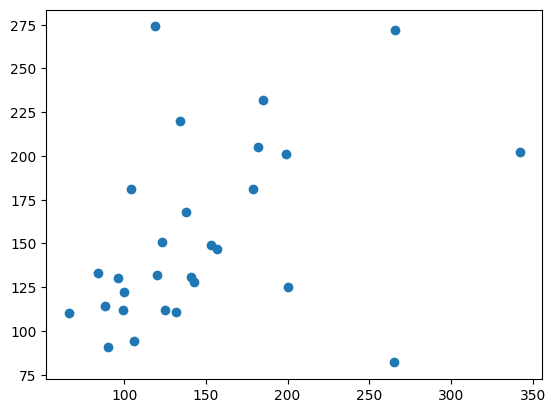

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# Dataset
b_data = np.genfromtxt("/content/Dataset_ejem.csv", skip_header=3, delimiter=',')
plt.scatter(b_data[:,2], b_data[:,3])

In [ ]:
# Función de media móvil
def moving_average(a, n=3) :
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n

In [ ]:
print(moving_average(b_data , n=3))

[113.33333333 156.66666667 103.33333333  57.         104.66666667
 158.66666667 199.66666667 120.          54.33333333  64.66666667
  92.66666667 183.         171.         132.66666667 168.66666667
 217.33333333 306.66666667 214.33333333 127.33333333 201.33333333
 280.33333333 346.         206.66666667  94.66666667 113.66666667
 149.         215.33333333 151.33333333  93.         107.
 146.33333333 221.33333333 164.66666667 105.66666667  83.
  99.         133.66666667  90.          51.33333333 136.33333333
 213.66666667 238.         125.66666667  40.66666667  54.33333333
  74.33333333 101.33333333  69.          42.66666667  56.33333333
  79.66666667 119.33333333  90.66666667  62.66666667  51.66666667
  58.33333333  91.          69.66666667  52.          68.66666667
  92.33333333 148.33333333 122.66666667  92.66666667  78.
  83.66666667 119.66666667  87.66666667  59.33333333  76.
 103.33333333 148.66666667 110.          74.33333333  88.
 115.33333333 166.         128.          87.666666

## File I/O  (Entrada/Salida de Archivos)

### Comma-separated values (CSV)

Un formato muy común para archivos de datos son los valores separados por comas (CSV) o formatos similares como TSV (valores separados por tabulaciones). Para leer datos de estos archivos en matrices de Numpy, podemos usar la función `numpy.genfromtxt`. Por ejemplo:

In [ ]:
!head stockholm_td_adj.dat

1800  1  1    -6.1    -6.1    -6.1 1
1800  1  2   -15.4   -15.4   -15.4 1
1800  1  3   -15.0   -15.0   -15.0 1
1800  1  4   -19.3   -19.3   -19.3 1
1800  1  5   -16.8   -16.8   -16.8 1
1800  1  6   -11.4   -11.4   -11.4 1
1800  1  7    -7.6    -7.6    -7.6 1
1800  1  8    -7.1    -7.1    -7.1 1
1800  1  9   -10.1   -10.1   -10.1 1
1800  1 10    -9.5    -9.5    -9.5 1


El script !head stockholm_td_adj.dat en Python no es código Python directamente. El signo de exclamación ! al principio de la línea indica que se está ejecutando un comando de shell (sistema operativo), no una instrucción Python.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:

data = np.genfromtxt('stockholm_td_adj.dat')

In [ ]:
data.shape

(77431, 7)

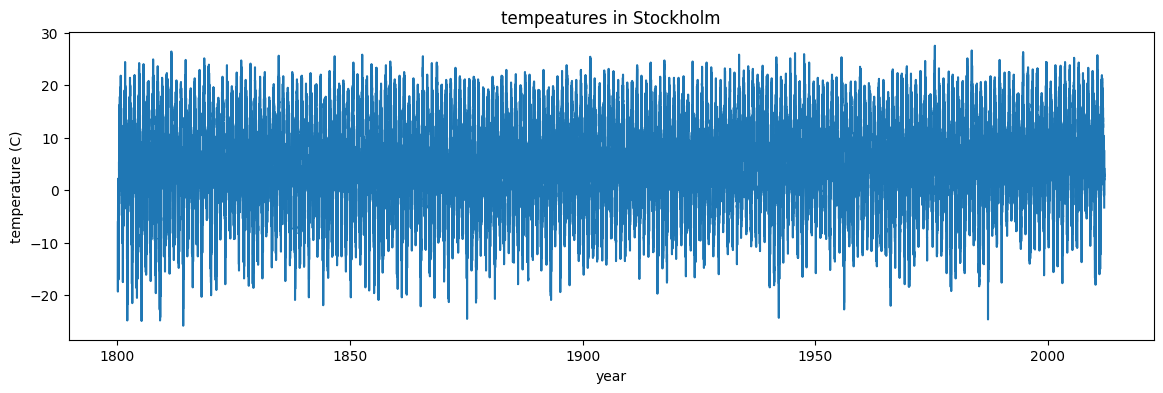

In [ ]:
fig, ax = plt.subplots(figsize=(14,4))
ax.plot(data[:,0]+data[:,1]/12.0+data[:,2]/365, data[:,5])
ax.axis('tight')
ax.set_title('tempeatures in Stockholm')
ax.set_xlabel('year')
ax.set_ylabel('temperature (C)');

Usando `numpy.savetxt` podemos almacenar una matriz Numpy en un archivo en formato CSV:

In [ ]:
M = np.random.rand(3,3)

M

array([[0.87995217, 0.33932653, 0.41632366],
       [0.7429467 , 0.70221398, 0.35588363],
       [0.12053694, 0.08969095, 0.6271103 ]])

In [ ]:
np.savetxt("random-matrix.csv", M)

In [ ]:
!cat random-matrix.csv

8.799521663786606940e-01 3.393265333412532891e-01 4.163236647449402028e-01
7.429466992612566711e-01 7.022139830270843763e-01 3.558836257652513435e-01
1.205369376304977758e-01 8.969094589636616988e-02 6.271103027518081241e-01


cuando ejecutas  `!cat random-matrix.csv:

1.   Le indicas al entorno de Python (si es un entorno interactivo como Jupyter Notebook o Google Colab) que ejecute un comando de shell.
2.   El comando `cat` es ejecutado sobre el archivo random-matrix.csv.
3.  `cat` leerá el archivo random-matrix.csv de principio a fin y mostrará todo su contenido directamente en la salida de tu celda de Jupyter/Colab.

In [ ]:
np.savetxt("random-matrix.csv", M, fmt='%.5f') # fmt specifies the format

!cat random-matrix.csv

0.87995 0.33933 0.41632
0.74295 0.70221 0.35588
0.12054 0.08969 0.62711


### Formato de archivo nativo de Numpy

Útil para almacenar y leer datos de matrices numpy. Use las funciones `numpy.save` y `numpy.load`:

In [ ]:
np.save("random-matrix.npy", M)

!file random-matrix.npy

random-matrix.npy: NumPy array, version 1.0, header length 118


In [ ]:
np.load("random-matrix.npy")

array([[0.87995217, 0.33932653, 0.41632366],
       [0.7429467 , 0.70221398, 0.35588363],
       [0.12053694, 0.08969095, 0.6271103 ]])

## Más propiedades de las matrices numpy

In [ ]:
M.itemsize # bytes por elemento

8

In [ ]:
M.nbytes # número de bytes

72

In [ ]:
M.ndim # número de dimensiones

2

## Manipulación de matrices

### Indexación

Podemos indexar elementos de una matriz utilizando corchetes e índices:

In [ ]:
# M es un vector, y tiene solo una dimensión, tomando un índice
M[0]

array([0.87995217, 0.33932653, 0.41632366])

In [ ]:
# M es una matriz, o una matriz bidimensional, que toma dos índices
M[1,1]

np.float64(0.7022139830270844)

Si omitimos un índice de una matriz multidimensional, devuelve la fila completa (o, en general, una matriz de N-1 dimensiones)

In [ ]:
M

array([[ 0.77872576,  0.40043577,  0.66254019],
       [ 0.60410063,  0.4791374 ,  0.8237106 ],
       [ 0.96856318,  0.15459644,  0.96082399]])

In [ ]:
M[1]

array([ 0.60410063,  0.4791374 ,  0.8237106 ])

Lo mismo se puede lograr utilizando `:` en lugar de un índice:

In [ ]:
M[1,:] # fila 1

array([ 0.60410063,  0.4791374 ,  0.8237106 ])

In [ ]:
M[:,1] # columna 1

array([ 0.40043577,  0.4791374 ,  0.15459644])

Podemos asignar nuevos valores a los elementos de una matriz mediante indexación:

In [ ]:
M[0,0] = 1

In [ ]:
M

array([[ 1.        ,  0.40043577,  0.66254019],
       [ 0.60410063,  0.4791374 ,  0.8237106 ],
       [ 0.96856318,  0.15459644,  0.96082399]])

In [ ]:
# También funciona para filas y columnas.
M[1,:] = 0
M[:,2] = -1

In [ ]:
M

array([[ 1.        ,  0.40043577, -1.        ],
       [ 0.        ,  0.        , -1.        ],
       [ 0.96856318,  0.15459644, -1.        ]])

### Segmentación de índice

La segmentación de índice es el nombre técnico de la sintaxis `M[lower:upper:step]` para extraer parte de una matriz:

In [ ]:
A = array([1,2,3,4,5])
A

array([1, 2, 3, 4, 5])

In [ ]:
A[1:3]

array([2, 3])

Las porciones son *mutables*: si se les asigna un nuevo valor, se modifica la matriz original de la que se extrajo la porción:

In [ ]:
A[1:3] = [-2,-3]

A

array([ 1, -2, -3,  4,  5])

We can omit any of the three parameters in `M[lower:upper:step]`:

In [ ]:
A[::] # inferior, superior, paso, todos toman los valores predeterminados

array([ 1, -2, -3,  4,  5])

In [ ]:
A[::2] # El paso es 2, los valores predeterminados inferior y superior son el principio y el final de la matriz

array([ 1, -3,  5])

In [ ]:
A[:3] # primeros tres elementos

array([ 1, -2, -3])

In [ ]:
A[3:] # elementos del índice 3

array([4, 5])

Los índices negativos cuentan desde el final de la matriz (índice positivo desde el principio):

In [ ]:
A = array([1,2,3,4,5])

In [ ]:
A[-1] #el último elemento de la matriz

5

In [ ]:
A[-3:] # los últimos tres elementos

array([3, 4, 5])

La segmentación de índice funciona exactamente de la misma manera para matrices multidimensionales:

In [ ]:
A = array([[n+m*10 for n in range(5)] for m in range(5)])

A

array([[ 0,  1,  2,  3,  4],
       [10, 11, 12, 13, 14],
       [20, 21, 22, 23, 24],
       [30, 31, 32, 33, 34],
       [40, 41, 42, 43, 44]])

In [ ]:
# un bloque de la matriz original
A[1:4, 1:4]

array([[11, 12, 13],
       [21, 22, 23],
       [31, 32, 33]])

In [ ]:
# pasos
A[::2, ::2]

array([[ 0,  2,  4],
       [20, 22, 24],
       [40, 42, 44]])

### Indexación sofisticada

La indexación elegante es el nombre que se da cuando se utiliza una matriz o lista en lugar de un índice:

In [ ]:
row_indices = [1, 2, 3]
A[row_indices]

array([[10, 11, 12, 13, 14],
       [20, 21, 22, 23, 24],
       [30, 31, 32, 33, 34]])

In [ ]:
col_indices = [1, 2, -1] # Recuerde, el índice -1 significa el último elemento.
A[row_indices, col_indices]

array([11, 22, 34])

También podemos utilizar máscaras de índice: Si la máscara de índice es un array Numpy de tipo de datos `bool`, entonces un elemento se selecciona (Verdadero) o no (Falso) dependiendo del valor de la máscara de índice en la posición de cada elemento:

In [ ]:
B = array([n for n in range(5)])
B

array([0, 1, 2, 3, 4])

In [ ]:
row_mask = array([True, False, True, False, False])
B[row_mask]

array([0, 2])

In [ ]:
# lo mismo
row_mask = array([1,0,1,0,0], dtype=bool)
B[row_mask]

array([0, 2])

Esta característica es muy útil para seleccionar elementos condicionalmente de una matriz, utilizando por ejemplo operadores de comparación:

In [ ]:
x = arange(0, 10, 0.5)
x

array([ 0. ,  0.5,  1. ,  1.5,  2. ,  2.5,  3. ,  3.5,  4. ,  4.5,  5. ,
        5.5,  6. ,  6.5,  7. ,  7.5,  8. ,  8.5,  9. ,  9.5])

In [ ]:
mask = (5 < x) * (x < 7.5)

mask

array([False, False, False, False, False, False, False, False, False,
       False, False,  True,  True,  True,  True, False, False, False,
       False, False], dtype=bool)

In [ ]:
x[mask]

array([ 5.5,  6. ,  6.5,  7. ])

## Funciones para extraer datos de matrices y crear matrices

### dónde

La máscara de índice se puede convertir en índice de posición utilizando la función where

In [ ]:
indices = where(mask)

indices

(array([11, 12, 13, 14]),)

In [ ]:
x[indices] # Esta indexación es equivalente a la indexación elegante x[máscara]

array([ 5.5,  6. ,  6.5,  7. ])

### diag

Con la función diag también podemos extraer la diagonal y subdiagonales de un array:

In [ ]:
diag(A)

array([ 0, 11, 22, 33, 44])

In [ ]:
diag(A, -1)

array([10, 21, 32, 43])

### llevar

La función `take` es similar a la indexación elegante descrita anteriormente:

In [ ]:
v2 = arange(-3,3)
v2

array([-3, -2, -1,  0,  1,  2])

In [ ]:
row_indices = [1, 3, 5]
v2[row_indices] # indexación sofisticada

array([-2,  0,  2])

In [ ]:
v2.take(row_indices)

array([-2,  0,  2])

Pero `take` también funciona en listas y otros objetos:

In [ ]:
take([-3, -2, -1,  0,  1,  2], row_indices)

array([-2,  0,  2])

### elegir

Construye una matriz seleccionando elementos de varias matrices:

In [ ]:
which = [1, 0, 1, 0]
choices = [[-2,-2,-2,-2], [5,5,5,5]]

choose(which, choices)

array([ 5, -2,  5, -2])

## Álgebra lineal

Vectorizar código es clave para escribir cálculos numéricos eficientes con Python/Numpy. Esto significa que, en la medida de lo posible, un programa debe formularse en términos de operaciones matriciales y vectoriales, como la multiplicación de matrices.

### Operaciones con matrices escalares

Podemos utilizar los operadores aritméticos habituales para multiplicar, sumar, restar y dividir matrices con números escalares.

In [ ]:
v1 = arange(0, 5)

In [ ]:
v1 * 2

array([0, 2, 4, 6, 8])

In [ ]:
v1 + 2

array([2, 3, 4, 5, 6])

In [ ]:
A * 2, A + 2

(array([[ 0,  2,  4,  6,  8],
        [20, 22, 24, 26, 28],
        [40, 42, 44, 46, 48],
        [60, 62, 64, 66, 68],
        [80, 82, 84, 86, 88]]), array([[ 2,  3,  4,  5,  6],
        [12, 13, 14, 15, 16],
        [22, 23, 24, 25, 26],
        [32, 33, 34, 35, 36],
        [42, 43, 44, 45, 46]]))

### Operaciones de matriz a matriz elemento por elemento

Cuando sumamos, restamos, multiplicamos y dividimos matrices entre sí, el comportamiento predeterminado son operaciones **elemento por elemento**:

In [ ]:
A * A # multiplicación elemento por elemento

array([[   0,    1,    4,    9,   16],
       [ 100,  121,  144,  169,  196],
       [ 400,  441,  484,  529,  576],
       [ 900,  961, 1024, 1089, 1156],
       [1600, 1681, 1764, 1849, 1936]])

In [ ]:
v1 * v1

array([ 0,  1,  4,  9, 16])

Si multiplicamos matrices con formas compatibles, obtenemos una multiplicación elemento por elemento de cada fila:

In [ ]:
A.shape, v1.shape

((5, 5), (5,))

In [ ]:
A * v1

array([[  0,   1,   4,   9,  16],
       [  0,  11,  24,  39,  56],
       [  0,  21,  44,  69,  96],
       [  0,  31,  64,  99, 136],
       [  0,  41,  84, 129, 176]])

### Álgebra matricial

¿Qué pasa con la multiplicación de matrices? Hay dos maneras. Podemos usar la función `dot`, que aplica una multiplicación matriz-matriz, matriz-vector o vector interno a sus dos argumentos:

In [ ]:
dot(A, A)

array([[ 300,  310,  320,  330,  340],
       [1300, 1360, 1420, 1480, 1540],
       [2300, 2410, 2520, 2630, 2740],
       [3300, 3460, 3620, 3780, 3940],
       [4300, 4510, 4720, 4930, 5140]])

In [ ]:
dot(A, v1)

array([ 30, 130, 230, 330, 430])

In [ ]:
dot(v1, v1)

30

Como alternativa, podemos convertir los objetos de matriz al tipo `matrix`. Esto modifica el comportamiento de los operadores aritméticos estándar `+, -, *` para usar álgebra matricial.

In [ ]:
M = matrix(A)
v = matrix(v1).T # Conviértalo en un vector columna

In [ ]:
v

matrix([[0],
        [1],
        [2],
        [3],
        [4]])

In [ ]:
M * M

matrix([[ 300,  310,  320,  330,  340],
        [1300, 1360, 1420, 1480, 1540],
        [2300, 2410, 2520, 2630, 2740],
        [3300, 3460, 3620, 3780, 3940],
        [4300, 4510, 4720, 4930, 5140]])

In [ ]:
M * v

matrix([[ 30],
        [130],
        [230],
        [330],
        [430]])

In [ ]:
# producto interno
v.T * v

matrix([[30]])

In [ ]:
# Con objetos matriciales, se aplica el álgebra matricial estándar.
v + M*v

matrix([[ 30],
        [131],
        [232],
        [333],
        [434]])

Si intentamos sumar, restar o multiplicar objetos con formas incompatibles obtenemos un error:

In [ ]:
v = matrix([1,2,3,4,5,6]).T

In [ ]:
shape(M), shape(v)

((5, 5), (6, 1))

In [ ]:
M * v

ValueError: shapes (5,5) and (6,1) not aligned: 5 (dim 1) != 6 (dim 0)

Consulte también las funciones relacionadas: interna, externa, cruz, kron, tensordot. Pruebe, por ejemplo, help(kron).

### Transformaciones de matriz/matriz

Anteriormente, usamos `.T` para transponer el objeto matricial `v`. También podríamos haber usado la función `transpose` para lograr lo mismo.

Otras funciones matemáticas que transforman objetos matriciales son:

In [ ]:
C = matrix([[1j, 2j], [3j, 4j]])
C

matrix([[ 0.+1.j,  0.+2.j],
        [ 0.+3.j,  0.+4.j]])

In [ ]:
conjugate(C)

matrix([[ 0.-1.j,  0.-2.j],
        [ 0.-3.j,  0.-4.j]])

Conjugado hermítico: transposición + conjugado

In [ ]:
C.H

matrix([[ 0.-1.j,  0.-3.j],
        [ 0.-2.j,  0.-4.j]])

Podemos extraer las partes reales e imaginarias de matrices de valores complejos usando `real` e `imag`:

In [ ]:
real(C) # same as: C.real

matrix([[ 0.,  0.],
        [ 0.,  0.]])

In [ ]:
imag(C) # same as: C.imag

matrix([[ 1.,  2.],
        [ 3.,  4.]])

O el argumento complejo y el valor absoluto

In [ ]:
angle(C+1) # Atención usuarios de MATLAB: se utiliza ángulo en lugar de argumento.

array([[ 0.78539816,  1.10714872],
       [ 1.24904577,  1.32581766]])

In [ ]:
abs(C)

matrix([[ 1.,  2.],
        [ 3.,  4.]])

### Cálculos matriciales

#### Inverso

In [ ]:
linalg.inv(C) # equivalente a C.I.

matrix([[ 0.+2.j ,  0.-1.j ],
        [ 0.-1.5j,  0.+0.5j]])

In [ ]:
C.I * C

matrix([[  1.00000000e+00+0.j,   4.44089210e-16+0.j],
        [  0.00000000e+00+0.j,   1.00000000e+00+0.j]])

#### Determinante

In [ ]:
linalg.det(C)

(2.0000000000000004+0j)

In [ ]:
linalg.det(C.I)

(0.50000000000000011+0j)

### Proceso de datos

A menudo resulta útil almacenar conjuntos de datos en matrices de Numpy. Numpy ofrece diversas funciones para calcular estadísticas de conjuntos de datos en matrices.

Por ejemplo, calculemos algunas propiedades del conjunto de datos de temperatura de Estocolmo utilizado anteriormente.

In [ ]:
# Recordatorio, el conjunto de datos de temperatura se almacena en la variable de datos:
shape(data)

(77431, 7)

#### significar

In [ ]:
# Los datos de temperatura están en la columna 3
mean(data[:,3])

6.1971096847515854

La temperatura media diaria en Estocolmo durante los últimos 200 años ha sido de unos 6,2 °C.

#### desviaciones estándar y varianza

In [ ]:
std(data[:,3]), var(data[:,3])

(8.2822716213405734, 68.596023209663414)

#### mín. y máx.

In [ ]:
# temperatura media diaria más baja
data[:,3].min()

-25.800000000000001

In [ ]:
# temperatura media diaria más alta
data[:,3].max()

28.300000000000001

#### suma, prod y trace

In [ ]:
d = arange(0, 10)
d

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [ ]:
# resumir todos los elementos
sum(d)

45

In [ ]:
# producto de todos los elementos
prod(d+1)

3628800

In [ ]:
# suma acumulada
cumsum(d)

array([ 0,  1,  3,  6, 10, 15, 21, 28, 36, 45])

In [ ]:
# producto acumulativo
cumprod(d+1)

array([      1,       2,       6,      24,     120,     720,    5040,
         40320,  362880, 3628800])

In [ ]:
# La misma que: Diag (A) .Sum ()
trace(A)

110

### Cálculos sobre subconjuntos de matrices

Podemos realizar cálculos con subconjuntos de datos en un array mediante indexación, indexación sofisticada y otros métodos de extracción de datos de un array (descritos anteriormente).

Por ejemplo, volvamos al conjunto de datos de temperatura:

In [ ]:
!head -n 3 stockholm_td_adj.dat

1800  1  1    -6.1    -6.1    -6.1 1
1800  1  2   -15.4   -15.4   -15.4 1
1800  1  3   -15.0   -15.0   -15.0 1


El formato de los datos es: año, mes, día, temperatura media diaria, mínima, máxima y ubicación.

Si nos interesa la temperatura media solo de un mes en particular, por ejemplo, febrero, podemos crear una máscara de índice y usarla para seleccionar solo los datos de ese mes mediante:

In [ ]:
unique(data[:,1]) # La columna del mes toma valores del 1 al 12

array([  1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,  11.,
        12.])

In [ ]:
mask_feb = data[:,1] == 2

In [ ]:
# Los datos de temperatura están en la columna 3
mean(data[mask_feb,3])

-3.2121095707365961

Con estas herramientas, disponemos de potentes capacidades de procesamiento de datos. Por ejemplo, para extraer las temperaturas medias mensuales de cada mes del año, solo se necesitan unas pocas líneas de código:

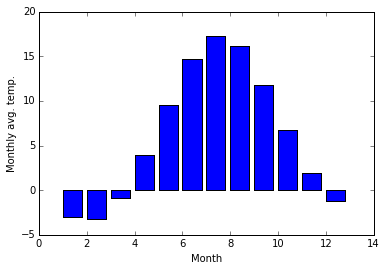

In [ ]:
months = arange(1,13)
monthly_mean = [mean(data[data[:,1] == month, 3]) for month in months]

fig, ax = plt.subplots()
ax.bar(months, monthly_mean)
ax.set_xlabel("Month")
ax.set_ylabel("Monthly avg. temp.");

### Cálculos con datos de dimensiones superiores

Cuando se aplican funciones como `min`, `max`, etc. a matrices multidimensionales, a veces resulta útil aplicar el cálculo a toda la matriz y, a veces, solo a cada fila o columna. Mediante el argumento `axis`, podemos especificar el comportamiento de estas funciones:

In [ ]:
m = random.rand(3,3)
m

array([[ 0.2850926 ,  0.17302017,  0.17748378],
       [ 0.80070487,  0.45527067,  0.61277451],
       [ 0.11372793,  0.43608703,  0.87010206]])

In [ ]:
# máximo global
m.max()

0.87010206156754955

In [ ]:
# máximo en cada columna
m.max(axis=0)

array([ 0.80070487,  0.45527067,  0.87010206])

In [ ]:
# maximo
m.max(axis=1)

NameError: name 'm' is not defined

Muchas otras funciones y métodos en las clases `array` y `matrix` aceptan el mismo argumento de palabra clave `axis` (opcional).

## Remodelación, redimensionamiento y apilamiento de matrices

La forma de una matriz Numpy se puede modificar sin copiar los datos subyacentes, lo que la convierte en una operación rápida incluso para matrices grandes.

In [ ]:
A

array([[ 0,  1,  2,  3,  4],
       [10, 11, 12, 13, 14],
       [20, 21, 22, 23, 24],
       [30, 31, 32, 33, 34],
       [40, 41, 42, 43, 44]])

In [ ]:
n, m = A.shape

In [ ]:
B = A.reshape((1,n*m))
B

array([[ 0,  1,  2,  3,  4, 10, 11, 12, 13, 14, 20, 21, 22, 23, 24, 30, 31,
        32, 33, 34, 40, 41, 42, 43, 44]])

In [ ]:
B[0,0:5] = 5 # modificar la matriz

B

NameError: name 'B' is not defined

In [ ]:
A # y la variable original también cambia. B es solo una vista diferente de los mismos datos.

array([[ 5,  5,  5,  5,  5],
       [10, 11, 12, 13, 14],
       [20, 21, 22, 23, 24],
       [30, 31, 32, 33, 34],
       [40, 41, 42, 43, 44]])

También podemos usar la función `flatten` para convertir un array de mayor dimensión en un vector. Sin embargo, esta función crea una copia de los datos.

In [ ]:
B = A.flatten()

B

array([ 5,  5,  5,  5,  5, 10, 11, 12, 13, 14, 20, 21, 22, 23, 24, 30, 31,
       32, 33, 34, 40, 41, 42, 43, 44])

In [ ]:
B[0:5] = 10

B

array([10, 10, 10, 10, 10, 10, 11, 12, 13, 14, 20, 21, 22, 23, 24, 30, 31,
       32, 33, 34, 40, 41, 42, 43, 44])

In [ ]:
A # ahora A no ha cambiado, porque los datos de B son una copia de los de A, no se refieren a los mismos datos

array([[ 5,  5,  5,  5,  5],
       [10, 11, 12, 13, 14],
       [20, 21, 22, 23, 24],
       [30, 31, 32, 33, 34],
       [40, 41, 42, 43, 44]])

## Añadiendo una nueva dimensión: newaxis

Con `newaxis`, podemos insertar nuevas dimensiones en una matriz, por ejemplo convirtiendo un vector en una matriz de columnas o filas:

In [ ]:
v = array([1,2,3])

In [ ]:
shape(v)

(3,)

In [ ]:
# Haz una matriz columna del vector v
v[:, newaxis]

array([[1],
       [2],
       [3]])

In [ ]:
# matriz de columnas
v[:,newaxis].shape

(3, 1)

In [ ]:
# matriz de filas
v[newaxis,:].shape

(1, 3)

## Apilamiento y repetición de matrices

Usando las funciones repeat, tile, vstack, hstack y concatenate podemos crear vectores y matrices más grandes a partir de vectores y matrices más pequeños:

### mosaico y repetir

In [ ]:
a = array([[1, 2], [3, 4]])

In [ ]:
# repite cada elemento 3 veces
repeat(a, 3)

array([1, 1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 4])

In [ ]:
# teselar la matriz 3 veces
tile(a, 3)

array([[1, 2, 1, 2, 1, 2],
       [3, 4, 3, 4, 3, 4]])

### concatenar

In [ ]:
b = array([[5, 6]])

In [ ]:
concatenate((a, b), axis=0)

array([[1, 2],
       [3, 4],
       [5, 6]])

In [ ]:
concatenate((a, b.T), axis=1)

array([[1, 2, 5],
       [3, 4, 6]])

### hstack y vstack

In [ ]:
vstack((a,b))

array([[1, 2],
       [3, 4],
       [5, 6]])

In [ ]:
hstack((a,b.T))

array([[1, 2, 5],
       [3, 4, 6]])

## Copia y "copia profunda"

Para lograr un alto rendimiento, las asignaciones en Python no suelen copiar los objetos subyacentes. Esto es importante, por ejemplo, al transferir objetos entre funciones, para evitar una copia excesiva de memoria cuando no es necesaria (término técnico: transferencia por referencia).

In [ ]:
A = array([[1, 2], [3, 4]])

A

array([[1, 2],
       [3, 4]])

In [ ]:
# Ahora B se refiere a los mismos datos de la matriz que A
B = A

In [ ]:
# cambiar B afecta a A
B[0,0] = 10

B

array([[10,  2],
       [ 3,  4]])

In [ ]:
A

array([[10,  2],
       [ 3,  4]])

Si queremos evitar este comportamiento, de modo que cuando obtengamos un nuevo objeto completamente independiente `B` copiado de `A`, entonces necesitamos hacer una llamada "copia profunda" usando la función `copy`:

In [ ]:
B = copy(A)

In [ ]:
# Ahora, si modificamos B, A no se ve afectada.
B[0,0] = -5

B

array([[-5,  2],
       [ 3,  4]])

In [ ]:
A

array([[10,  2],
       [ 3,  4]])

## Iteración sobre elementos de la matriz

Generalmente, queremos evitar iterar sobre los elementos de los arrays siempre que sea posible (a toda costa). Esto se debe a que, en un lenguaje interpretado como Python (o MATLAB), las iteraciones son muy lentas en comparación con las operaciones vectorizadas.

Sin embargo, a veces las iteraciones son inevitables. En estos casos, el bucle «for» de Python es la forma más conveniente de iterar sobre un array:

In [ ]:
v = array([1,2,3,4])

for element in v:
    print(element)

1
2
3
4


In [ ]:
M = array([[1,2], [3,4]])

for row in M:
    print("row", row)

    for element in row:
        print(element)

('row', array([1, 2]))
1
2
('row', array([3, 4]))
3
4


Cuando necesitamos iterar sobre cada elemento de un array y modificar sus elementos, es conveniente utilizar la función `enumerate` para obtener tanto el elemento como su índice en el bucle `for`:

In [ ]:
for row_idx, row in enumerate(M):
    print("row_idx", row_idx, "row", row)

    for col_idx, element in enumerate(row):
        print("col_idx", col_idx, "element", element)

        # Actualizar la matriz M: elevar al cuadrado cada elemento
        M[row_idx, col_idx] = element ** 2

('row_idx', 0, 'row', array([1, 2]))
('col_idx', 0, 'element', 1)
('col_idx', 1, 'element', 2)
('row_idx', 1, 'row', array([3, 4]))
('col_idx', 0, 'element', 3)
('col_idx', 1, 'element', 4)


In [ ]:
# cada elemento en M ahora está elevado al cuadrado
M

array([[ 1,  4],
       [ 9, 16]])

## Funciones vectorizadoras

Como ya se ha mencionado varias veces, para obtener un buen rendimiento, debemos evitar iterar sobre los elementos de nuestros vectores y matrices, y en su lugar utilizar algoritmos vectorizados. El primer paso para convertir un algoritmo escalar en un algoritmo vectorizado es asegurarnos de que las funciones que escribimos funcionen con entradas vectoriales.

In [ ]:
def Theta(x):
    """
    Scalar implementation of the Heaviside step function.
    """
    if x >= 0:
        return 1
    else:
        return 0

In [ ]:
import numpy as np

# Vectorize Theta
Theta_vec = np.vectorize(Theta)
Theta_vec(np.array([-3,-2,-1,0,1,2,3]))

array([0, 0, 0, 1, 1, 1, 1])

La función original Theta(x) está diseñada para recibir un solo número a la vez (un escalar).   

Si intentas pasarle una lista completa o un arreglo numérico directamente, Python entrará en pánico y lanzará un error.  


Estás tomando tu función individual y creando un "clon vitaminado" llamado Theta_vec. Esta nueva función sí entiende listas y arreglos.

Lo que hace internamente es comportarse como un repartidor: toma tu arreglo de números, saca cada número uno por uno, se lo entrega a tu función original Theta(x), anota el resultado y empaca todas las respuestas en un nuevo arreglo.



También podemos implementar la función para aceptar una entrada vectorial desde el principio (requiere más esfuerzo pero podría ofrecer un mejor rendimiento):

In [ ]:
def Theta(x):
    """
    Vector-aware implementation of the Heaviside step function.
    """
    return 1 * (x >= 0)

In [ ]:
Theta(np.array([-3,-2,-1,0,1,2,3]))

array([0, 0, 0, 1, 1, 1, 1])

In [ ]:
# Todavía funciona también para escalares
Theta(-1.2), Theta(2.6)

(0, 1)

## Uso de matrices en condiciones

Al usar matrices en condiciones, por ejemplo, declaraciones `if` y otras expresiones booleanas, es necesario usar `any` o `all`, lo que requiere que cualquiera o todos los elementos de la matriz se evalúen como `True`:

In [ ]:
M

array([[ 1,  4],
       [ 9, 16]])

In [ ]:
if (M > 5).any():
    print("at least one element in M is larger than 5")
else:
    print("no element in M is larger than 5")

at least one element in M is larger than 5


In [ ]:
if (M > 5).all():
    print("all elements in M are larger than 5")
else:
    print("all elements in M are not larger than 5")

all elements in M are not larger than 5


## Fundición de tipos

Dado que los arrays de Numpy tienen *tipo estático*, el tipo de un array no cambia una vez creado. Sin embargo, podemos convertir explícitamente un array de un tipo a otro mediante las funciones `astype` (véase también la función similar `asarray`). Esto siempre crea un nuevo array de un nuevo tipo:

In [ ]:
M.dtype

dtype('int64')

In [ ]:
M2 = M.astype(float)

M2

array([[  1.,   4.],
       [  9.,  16.]])

In [ ]:
M2.dtype

dtype('float64')

In [ ]:
M3 = M.astype(bool)

M3

array([[ True,  True],
       [ True,  True]], dtype=bool)

## Lectura adicional

* http://numpy.scipy.org
* http://scipy.org/Tentative_NumPy_Tutorial
* http://scipy.org/NumPy_for_Matlab_Users - A Numpy guide for MATLAB users.

## Versiones

In [ ]:
%reload_ext version_information

%version_information numpy

Software versions
Python 2.7.10 64bit [GCC 4.2.1 (Apple Inc. build 5577)]
IPython 3.2.1
OS Darwin 14.1.0 x86_64 i386 64bit
numpy 1.9.2
Sat Aug 15 11:02:09 2015 JST